# Proposed Model: Improved ResNet101 Architecture

# 1. Project Overview

**Proposed Model: Improved ResNet101 Architecture**

This notebook presents the enhanced architecture used for comparison in a 4-class brain MRI classification task.

# 2. Import Libraries

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D, Dropout, Dense, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm


# 3. Data Loading and Preprocessing

## Dataset

NOTE: The dataset is not included in this repository.

The code assumes the following directory structure:

- Training/
    - Glioma/
    - Meningioma/
    - Pituitary/
    - No Tumor/
- Testing/
    - Glioma/
    - Meningioma/
    - Pituitary/
    - No Tumor/

Please ensure your dataset follows this structure before running the code.

In [ ]:
# Initial settings
image_size = 224
labels = ['glioma_tumor', 'no_tumor', 'meningioma_tumor', 'pituitary_tumor']

X, y = [], []
X_no_tumor = []

# Loading images and labeling
for label in labels:
    folderPath = os.path.join('Training', label)
    for filename in tqdm(os.listdir(folderPath), desc=f"Loading Training Data - {label}"):
        img = cv2.imread(os.path.join(folderPath, filename))
        if img is not None:
            img = cv2.resize(img, (image_size, image_size))
            if label == "no_tumor":
                X_no_tumor.append(img)
            X.append(img)
            y.append(labels.index(label))

Loading Training Data - pituitary_tumor: 100%|██████████| 827/827 [00:01<00:00, 441.97it/s]


<ipython-input-4-5459f2884f20>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()), palette="viridis")


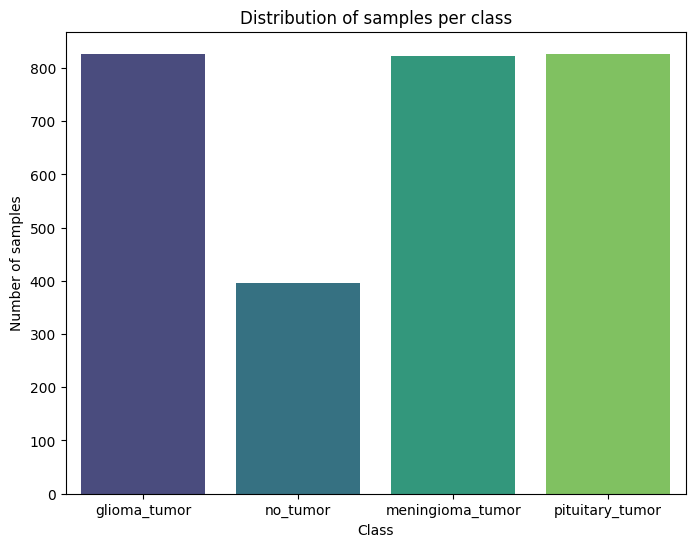

In [ ]:
# Counting the number of samples
label_counts = Counter(y)

# Displaying the number of samples
plt.figure(figsize=(8, 6))
sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()), palette="viridis")

plt.xticks(ticks=range(len(labels)), labels=labels)
plt.ylabel('Number of samples')
plt.xlabel('Class')
plt.title('Distribution of samples per class')
plt.show()


# 4. Data Augmentation

In [ ]:
# Data Augmentation for no_tumor
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

X_no_tumor = np.array(X_no_tumor, dtype=np.float32) / 255.0  # Normalization
y_no_tumor = [labels.index("no_tumor")] * len(X_no_tumor)

# Adding augmented data to Dataset
augmented_images = []
augmented_labels = []

for img in X_no_tumor:
    img = np.expand_dims(img, axis=0)
    aug_iter = datagen.flow(img, batch_size=1)
    for _ in range(1):
        aug_img = next(aug_iter)[0]
        augmented_images.append(aug_img)
        augmented_labels.append(labels.index("no_tumor"))

X.extend(augmented_images)
y.extend(augmented_labels)

# Normalization
X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)


# 5. Train-Test Split

In [ ]:
# Splitting data to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)

# One-Hot Encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes=len(labels))
y_test = tf.keras.utils.to_categorical(y_test, num_classes=len(labels))

print(f"Number of samples per class after Data Augmentation:")
for label in labels:
    print(f"{label}: {np.sum(y_train[:, labels.index(label)]) + np.sum(y_test[:, labels.index(label)])}")


Number of samples per class after Data Augmentation:
glioma_tumor: 826.0
no_tumor: 790.0
meningioma_tumor: 822.0
pituitary_tumor: 827.0


# 6. Model Architecture

Proposed model using ResNet101 with GlobalMaxPooling, additional Dense layers, Batch Normalization, and Dropout.

In [ ]:
# Loading the pre-trained ResNet101 model without the top layers
resnet = tf.keras.applications.ResNet101(
    weights='imagenet',
    include_top=False,
    input_shape=(image_size, image_size, 3)
)

x = resnet.output
x = GlobalMaxPooling2D()(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(rate=0.3)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(rate=0.2)(x)

x = Dense(4, activation='softmax')(x)

# Building the final model
model = Model(inputs=resnet.input, outputs=x)

# Compiling the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 43,217,668 (164.86 MB)

 Trainable params: 43,111,556 (164.46 MB)

 Non-trainable params: 106,112 (414.50 KB)

# 7. Training Setup

In [ ]:
# Tensorboard callback for logging training metrics
tensorboard = TensorBoard(log_dir='logs')

# Modelcheckpoint callback to save the best model
checkpoint = ModelCheckpoint("ProposedModel.keras", monitor="val_accuracy",
                             save_best_only=True, verbose=1)

# ReduceLROnPlateau callback to reduce learning rate if validation accuracy plateaus
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=2,
                              min_delta=0.0001, verbose=1)

# 8. Model Training

In [ ]:
history = model.fit(X_train,y_train,validation_split=0.1, epochs =25, verbose=1, batch_size=32,
                   callbacks=[tensorboard,checkpoint,reduce_lr])

Epoch 1/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7100 - loss: 0.7787   
Epoch 1: val_accuracy improved from -inf to 0.25573, saving model to ProposedModel.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.7113 - loss: 0.7753 - val_accuracy: 0.2557 - val_loss: 2.5761 - learning_rate: 5.0000e-04
Epoch 2/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.9257 - loss: 0.2217
Epoch 2: val_accuracy did not improve from 0.25573
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 547ms/step - accuracy: 0.9257 - loss: 0.2217 - val_accuracy: 0.2557 - val_loss: 6.0035 - learning_rate: 5.0000e-04
Epoch 3/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.9524 - loss: 0.1319
Epoch 3: val_accuracy did not improve from 0.25573

Epoch 3: ReduceLROnPlateau reducing learning rate to 5.0000002374872565e-05.
74/74 ━━━━━━━━━━━━━━━━━━━━ 39s 532ms/step - accuracy: 0.9524 - loss: 0.1319 - val_accuracy: 0.2557 - val_loss: 6.8052 - learning_rate: 5.0000e-04
Epoch 4/25
74/74 ━━━━━━━━━━━━━━━━━━━━

# 9. Evaluation

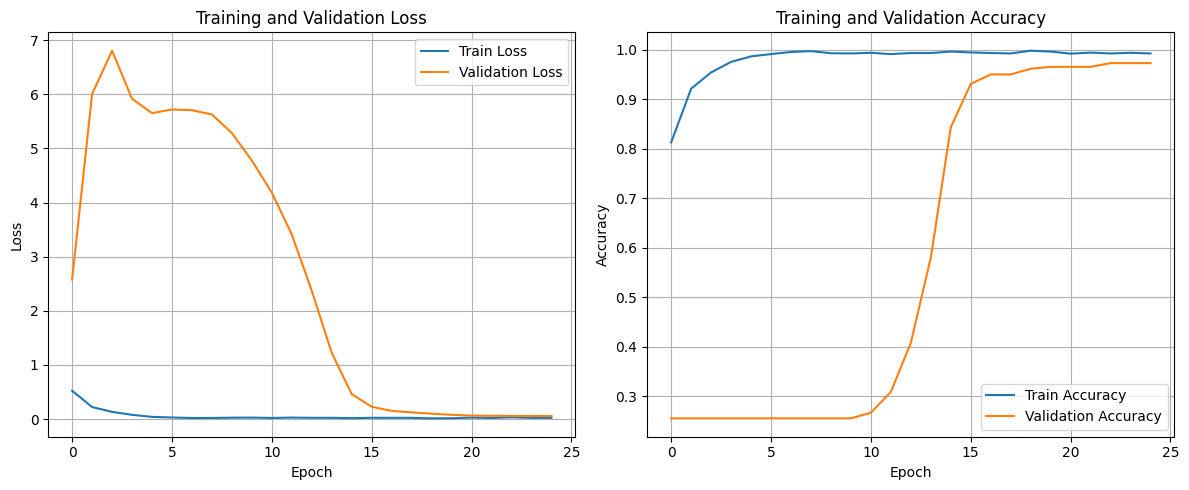

In [ ]:
# Plotting training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 567ms/step
Test Accuracy: 0.9755
Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.99      0.97      0.98       165
        no_tumor       0.98      0.98      0.98       158
meningioma_tumor       0.94      0.96      0.95       164
 pituitary_tumor       0.99      0.99      0.99       166

        accuracy                           0.98       653
       macro avg       0.98      0.98      0.98       653
    weighted avg       0.98      0.98      0.98       653



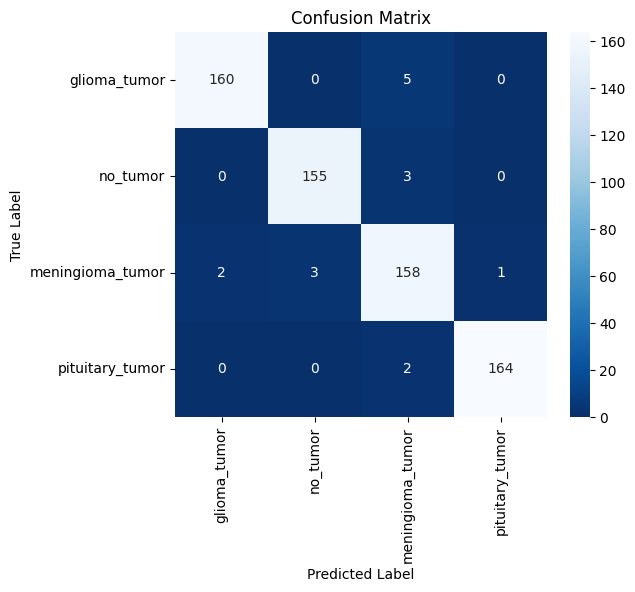

In [ ]:
# Model predictions on the test data
y_pred_test = model.predict(X_test)

# Converting predictions and true values from One-Hot to numerical class
y_pred_test_labels = np.argmax(y_pred_test, axis=1)
y_true_test_labels = np.argmax(y_test, axis=1)

# Calculating the model accuracy on the test data
accuracy = accuracy_score(y_true_test_labels, y_pred_test_labels)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification report
print("Classification Report:")
print(classification_report(y_true_test_labels, y_pred_test_labels, target_names=labels))

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true_test_labels, y_pred_test_labels), annot=True, fmt='d', cmap='Blues_r',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
